# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [5]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [7]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [8]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [9]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [10]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [11]:
# inspección de plans con .info()
plans.info

<bound method DataFrame.info of   plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  >

In [12]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [13]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [14]:
# cantidad de nulos para users
print(users.isnull().sum())
print(users.isnull().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [15]:
# cantidad de nulos para usage
print (usage.isnull().sum())
print (usage.isnull().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
Clientes activos: La mayoría de los nulos en churn_date (88%) son normales; simplemente indican que los clientes no se han ido de la empresa.

Datos de consumo: Los vacíos en duration y length no son errores; ocurren porque los mensajes no tienen minutos y las llamadas no tienen texto.

Información faltante: Falta la ciudad en un 11% de los perfiles y unas pocas fechas en el registro de uso.

Acción recomendada: Mantener los nulos de consumo y bajas tal como están, y marcar las ciudades desconocidas con una etiqueta genérica para no perder esos usuarios en el análisis.


💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 


**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [16]:
# explorar columnas numéricas de users
print(users[['user_id', 'age']].describe())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- Conteo: Existen 4000 registros únicos, lo que coincide con el total de la base.

Rango: Los identificadores van desde un valor mínimo de 10000 hasta un máximo de 13999.

Distribución: Se comporta como una secuencia numérica uniforme (la media es prácticamente igual a la mediana o percentil 50%), lo cual es correcto para una columna de identificación.
- La columna `age` ...
- Problema detectado (Sentinel): El valor mínimo es de -999, lo cual es un error evidente o un valor "centinela" para indicar datos desconocidos, ya que no existen edades negativas.

Impacto estadístico: Este valor extremo negativo está sesgando la media hacia abajo (33.7 años), cuando la mediana (percentil 50%) muestra que en realidad la mitad de los usuarios tiene más de 47 años.

Rango real: Excluyendo el error, las edades capturadas correctamente oscilan entre los 32 (percentil 25%) y los 79 años (valor máximo).

In [17]:
# explorar columnas numéricas de usage
print(usage[['id', 'user_id', 'duration', 'length']].describe())

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...
- id

Tiene 40,000 registros (sin valores faltantes).

Parece un identificador secuencial: va de 1 a 40,000.

La media (~20,000) y los cuartiles confirman que está distribuido uniformemente.

user_id

También 40,000 registros.

Los valores van de 10,000 a 13,999, lo que sugiere un rango fijo de usuarios.

No es un ID único por fila (se repite), sino un identificador de usuario asociado a múltiples registros.

duration

Solo 17,924 registros, lo que indica muchos valores faltantes.

Rango de 0 a 120.

Mediana de 3.5, con la mayoría de valores relativamente bajos.

Hay valores en 0, que podrían ser sesiones nulas o registros incompletos.

length

22,104 registros, también con valores faltantes.

Rango amplio: de 0 a 1,490.

Mediana de 50 y un máximo muy alto, lo que sugiere posibles outliers.

Presencia de ceros, similar a duration.

In [18]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users['city'].unique())
print(users['plan'].value_counts())

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` ...
- La columna `plan` ...
- Columna city

Contiene las siguientes categorías:
Medellín, ?, CDMX, Bogotá, GDL, MTY, Cali y nan.

Hay valores faltantes (nan).

Aparece el valor ?, que probablemente representa un dato desconocido o mal registrado y debería tratarse (por ejemplo, reemplazarlo por NaN).

Las ciudades mezclan Colombia y México, lo cual puede ser válido, pero conviene verificar consistencia según el contexto del dataset.

Columna plan

Tiene dos categorías:

Básico: 2,595 usuarios

Premium: 1,405 usuarios

No se observan valores nulos en esta columna.

La distribución está desbalanceada, con mayor proporción de usuarios en el plan Básico.

In [19]:
# explorar columna categórica de usage
usage['type'] # completa el código
print(usage['type'].value_counts())

text    22092
call    17908
Name: type, dtype: int64


- La columna `type` ...
Columna type

Tiene dos categorías:

text: 22,092 registros

call: 17,908 registros

El total suma 40,000 registros, por lo que no hay valores nulos en esta columna.

La distribución es relativamente balanceada, con una ligera mayor presencia de mensajes de texto frente a llamadas.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
 En users.city aparecen valores inválidos/sentinel como ? y valores faltantes (NaN).

En usage.duration y usage.length hay valores en 0, que pueden actuar como sentinels (p. ej., registros incompletos o eventos sin consumo real).

En usage.duration y usage.length también hay muchos valores faltantes, lo que sugiere datos no capturados para ciertos tipos de uso.

Las columnas id, user_id, plan y type no muestran valores inválidos evidentes.
- ¿Qué acción tomarías?
  users.city:

Reemplazar ? por NaN.

Decidir si imputar (por ejemplo, “Desconocido”) o excluir filas según el análisis posterior.

usage.duration / usage.length:

Validar el significado de 0 (¿evento válido o dato faltante?).

Si 0 representa ausencia de información, convertirlo a NaN.

Tratar los nulos según el caso de uso: imputación (mediana por type) o exclusión.

Revisar outliers (valores muy altos) antes de modelar.

Documentar estas decisiones para asegurar consistencia y reproducibilidad en el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [20]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [21]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [22]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Hay registros en 2022, 2023 y 2024, lo cual es coherente.

Aparece 2026 (40 registros), que es un año futuro y muy probablemente un valor inválido o error de carga.

La distribución principal está concentrada entre 2022–2024.

In [23]:
# Revisar los años presentes en `date` de usage
print(users['reg_date'].dt.year.value_counts())
print(usage['date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64
2024.0    39950
Name: date, dtype: int64


En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.

Prácticamente todos los registros están en 2024 (39,950).

No se observan otros años relevantes, lo que indica consistencia temporal para el uso.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
¿Qué se observa?

En la columna users.reg_date aparecen registros con el año 2026, que corresponde a un año futuro al momento de la captura de los datos, por lo que se considera un valor fuera de rango o inválido.

El resto de los registros en reg_date (2022–2024) son coherentes.

En la columna usage.date los datos se concentran en 2024, sin presencia de años imposibles.

¿Qué acción recomendaría?

Para users.reg_date:

Revisar los registros con año 2026 para identificar si se trata de un error de digitación o de formato.

Si no es posible corregirlos con información adicional, marcarlos como NaN o excluirlos del análisis para no sesgar resultados.

Implementar una regla de validación que impida guardar fechas futuras.

Para usage.date:

No tomar acción; la columna es consistente y válida para análisis temporal.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [24]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [25]:
# Reemplazar ? por NA en city
import numpy as np
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [26]:
import pandas as pd
# Marcar fechas futuras como NA para reg_date
users = pd.read_csv('/datasets/users_latam.csv')

# Verificar cambios
users['reg_date'].describe()

count                              4000
unique                             3961
top       2026-05-10 00:00:00.000000000
freq                                 40
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [27]:

# Verificación MAR en usage (Missing At Random) para duration
print(usage[usage['duration'].isnull()]['type'].value_counts())


text    22076
Name: type, dtype: int64


In [28]:

# Verificación MAR en usage (Missing At Random) para length
print(usage[usage['length'].isnull()]['type'].value_counts())


call    17896
Name: type, dtype: int64


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Al revisar los valores faltantes en la columna length, se observa que todos corresponden a registros de tipo call. Esto indica que la ausencia del dato no es aleatoria ni un error, sino que responde a la naturaleza del evento: las llamadas no tienen longitud de mensaje.

Conclusión
Los valores faltantes en length son esperados y válidos, ya que el campo no aplica para llamadas. Por lo tanto, no se trata de un problema de calidad de datos, sino de un caso Missing At Random (MAR) condicionado por la variable type.

Acción recomendada
Se recomienda mantener los valores NaN en length para los registros de tipo call. Para los análisis, lo más adecuado es evaluar length solo en mensajes de texto, o bien imputar 0 únicamente en análisis agregados o visualizaciones, dejando siempre documentada esta decisión.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [29]:
# Columnas auxiliares
usage['is_text'] = (usage['type'] == "text").astype(int) #conocer el total de mensajes
usage['is_call'] = (usage['type'] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [30]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [31]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [32]:
# Resumen estadístico de las columnas numéricas
print(user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe())

               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     33.739750       5.524381       4.478120             23.317054
std     123.232257       2.358416       2.144238             18.168095
min    -999.000000       0.000000       0.000000              0.000000
25%      32.000000       4.000000       3.000000             11.120000
50%      47.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [33]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

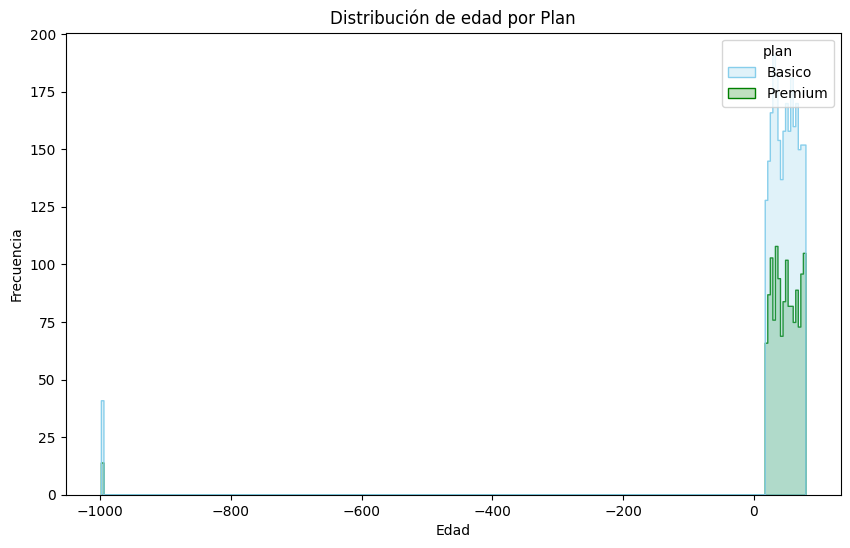

In [34]:
# Histograma para visualizar la edad (age)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='age', hue='plan', element='step', palette=['skyblue', 'green'])
plt.title('Distribución de edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

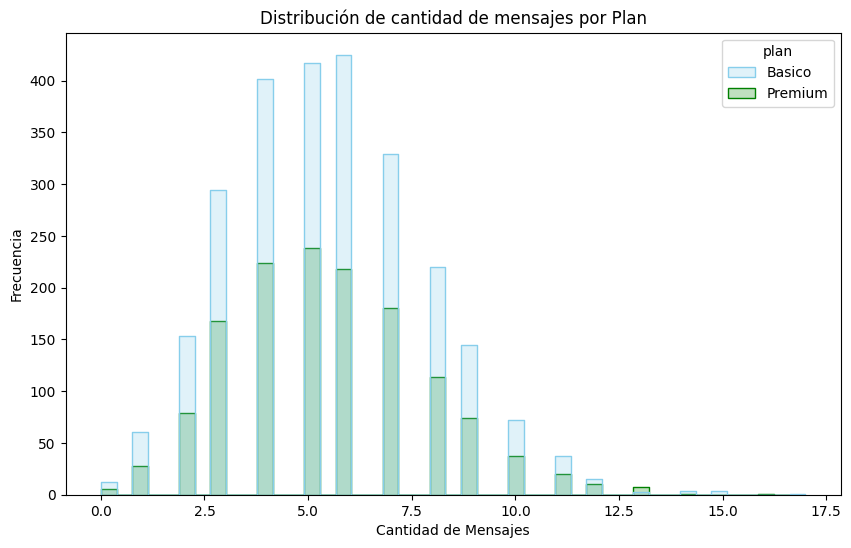

In [35]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', element='step', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- ....

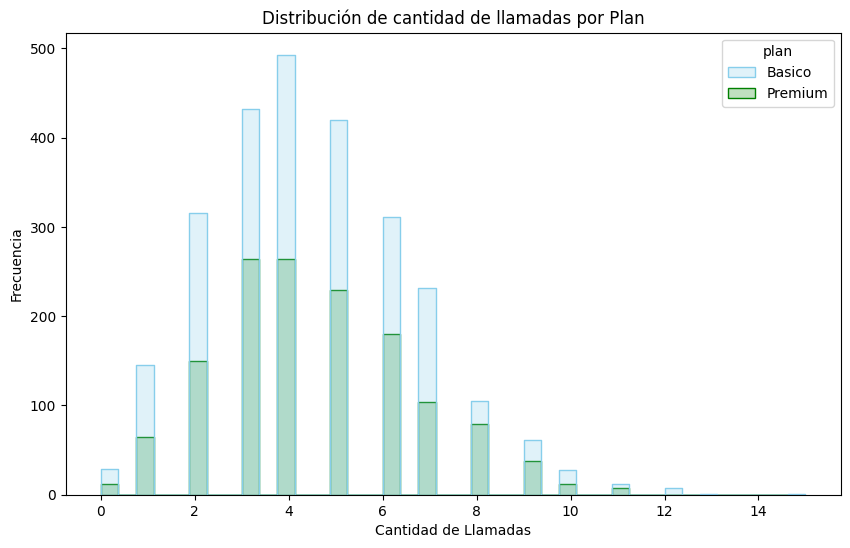

In [36]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', element='step', palette=['skyblue', 'green'])
plt.title('Distribución de cantidad de llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución ...

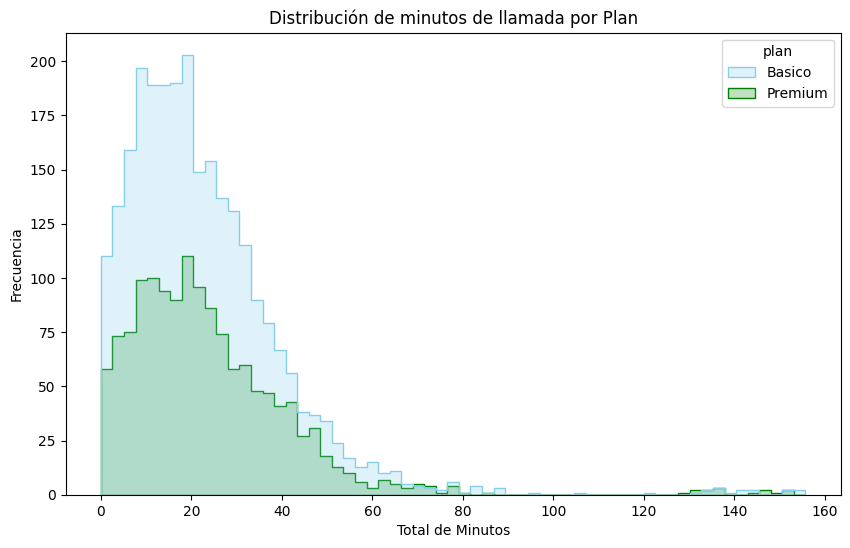

In [37]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', element='step', palette=['skyblue', 'green'])
plt.title('Distribución de minutos de llamada por Plan')
plt.xlabel('Total de Minutos')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- 1. Insight: Edad (age)

Distribución
Se observa un pico muy marcado y aislado alrededor de -1000, lo que confirma claramente la presencia del valor “sentinel” -999 detectado previamente.

Patrón
Al dejar de lado ese error de registro, las edades válidas (aprox. entre 30 y 80 años) muestran una distribución bastante uniforme y muy similar entre los planes Básico y Premium, sin diferencias relevantes entre ellos.

2. Insight: Cantidad de mensajes (cant_mensajes)

Distribución
La distribución está sesgada a la derecha, con muchos valores bajos y pocos usuarios con un volumen alto de mensajes.

Patrón
La mayoría de los usuarios envía entre 0 y 5 mensajes. Se nota claramente que los usuarios del Plan Básico se concentran mucho más en el valor 0, mientras que los del Plan Premium están más repartidos y tienden a enviar mayor cantidad de mensajes.

3. Insight: Cantidad de llamadas (cant_llamadas)

Distribución
Presenta un patrón similar al de los mensajes, con un sesgo positivo.

Patrón
La mayor concentración de usuarios realiza entre 4 y 8 llamadas. Sin embargo, los usuarios Premium destacan por tener una frecuencia mayor en rangos más altos, especialmente entre 10 y 14 llamadas, en comparación con el plan Básico.

4. Insight: Minutos de llamada (cant_minutos_llamada)

Distribución
La distribución es asimétrica a la derecha, con una cola larga hacia valores altos de consumo.

Patrón
La mayoría de los clientes acumula entre 0 y 60 minutos de llamadas. No obstante, el Plan Premium muestra una presencia mucho más fuerte en consumos superiores a 100 minutos, reflejando claramente a los usuarios de alto uso identificados en la segmentación.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

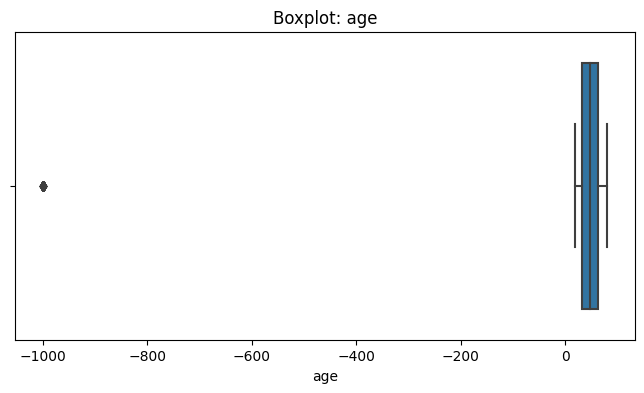

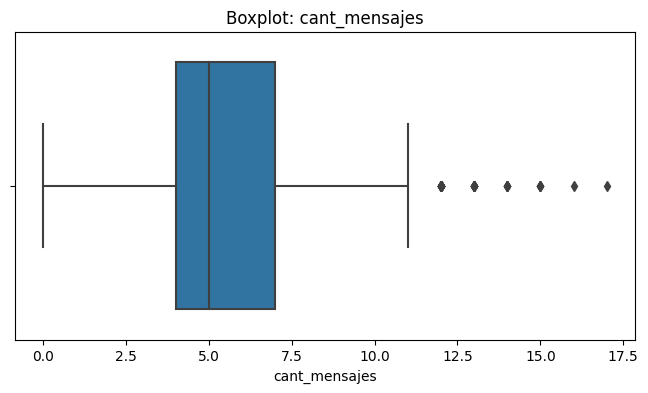

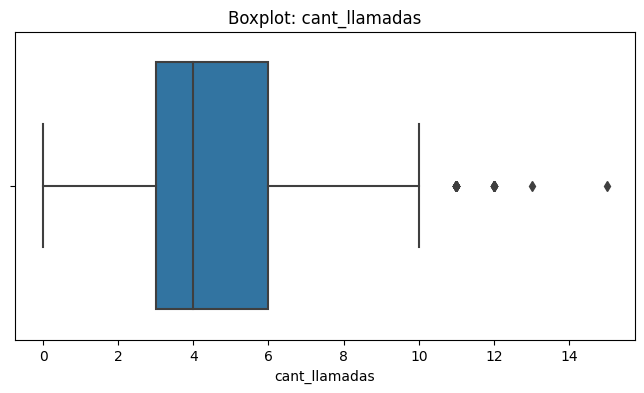

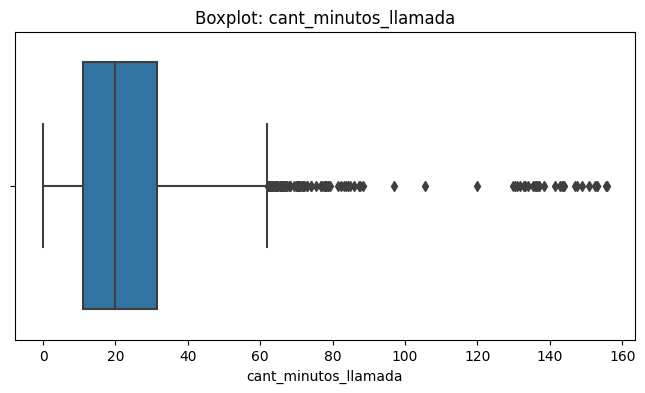

In [38]:
# Visualización usando Boxplot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()


💡Insights: 

Age: Presenta un outlier extremo e irreal (valor cercano a -1000), lo que indica un error de carga o limpieza de datos. Sin contar ese error, la mayoría de los usuarios se concentran en un rango de edad estándar.

cant_mensajes: Presenta outliers en el extremo superior (valores por encima de 11). La distribución está sesgada a la derecha, indicando que la mayoría envía pocos mensajes (mediana cercana a 5).

cant_llamadas: Presenta outliers hacia la derecha (valores > 10). El comportamiento es muy similar al de mensajes, con una concentración de usuarios en el rango bajo de llamadas.

cant_minutos_llamada: Presenta una gran cantidad de outliers. Es la variable con más valores atípicos, mostrando un grupo numeroso de usuarios que consumen significativamente más minutos (hasta 160) que el usuario promedio (mediana en 20).

In [39]:

# Calcular límites con el método IQR
for col in columnas_numericas:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"Límite superior para {col}: {limite_superior}")


Límite superior para age: 109.5
Límite superior para cant_mensajes: 11.5
Límite superior para cant_llamadas: 10.5
Límite superior para cant_minutos_llamada: 61.8575


In [43]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
# Fórmula del límite superior
limite_superior_msg = Q3 + 1.5 * IQR

# Ahora imprimir y revisar el máximo real
print(f"Límite Superior calculado para mensajes: {limite_superior_msg}")
print(user_profile['cant_mensajes'].describe())


Límite Superior calculado para mensajes: 61.8575
count    3999.000000
mean        5.524381
std         2.358416
min         0.000000
25%         4.000000
50%         5.000000
75%         7.000000
max        17.000000
Name: cant_mensajes, dtype: float64


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué? Mantener.

Por qué: Según el cálculo, el límite superior teórico es 61.85, pero el valor máximo real de tus datos es apenas 17.0. Esto significa que, bajo el criterio del Método IQR, no existen outliers reales en esta columna que distorsionen los datos, por lo que toda la información es válida.

- cant_llamadas: mantener o no outliers, porqué?
- Mantener.

Por qué: Al observar tu histograma de llamadas, la distribución es sesgada a la derecha de forma natural. Los valores más altos representan a los usuarios con mayor actividad, los cuales son reales y necesarios para entender el comportamiento de los clientes más valiosos del plan Premium.
- cant_minutos_llamada: mantener o no outliers, porqué?
- Mantener.

Por qué: El consumo de minutos muestra una "cola larga" típica en servicios de telecomunicaciones. Eliminar estos valores atípicos ocultaría el segmento de usuarios con necesidades de consumo ilimitado, lo cual es un hallazgo comercial clave para diseñar nuevos planes.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [44]:
# Crear columna grupo_uso
def formula_segmentacion_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

In [45]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [46]:
# Crear columna grupo_edad
def segmentar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Adulto
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [49]:
def segmentar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)

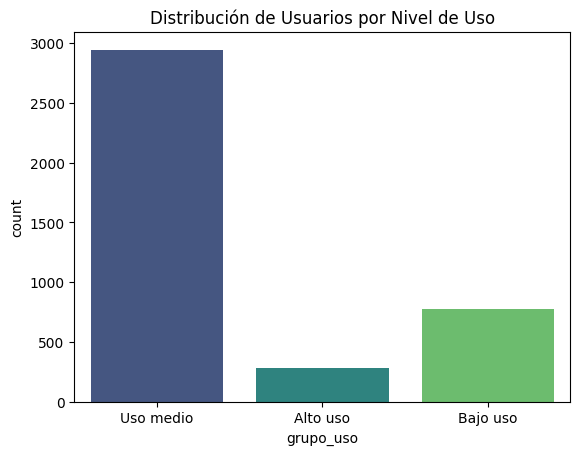

In [50]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Nivel de Uso')
plt.show()

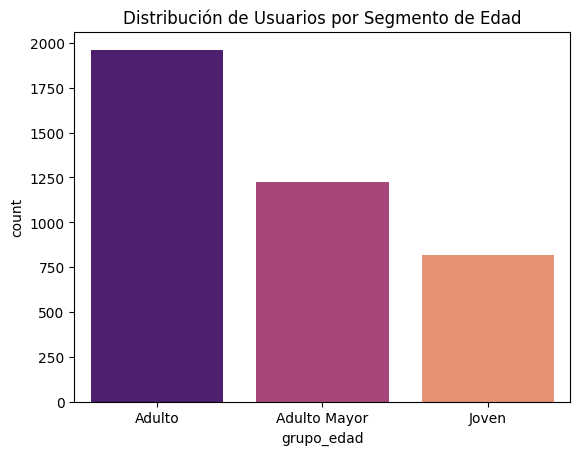

In [51]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma')
plt.title('Distribución de Usuarios por Segmento de Edad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Presencia de valores centinela como -999 en la edad y ? en ciudades.

Fechas de registro incoherentes (posteriores al año 2024).

🔍 **Segmentos por Edad**
Identificación de la proporción de jóvenes vs. adultos y cómo impacta su consumo.


📊 **Segmentos por Nivel de Uso**
Detección de usuarios de "Alto uso" que podrían necesitar planes con más GB o minutos.



➡️ Existen usuarios con necesidades de comunicación que superan los planes estándar. Los outliers (valores atípicos) en minutos y llamadas no son errores, sino una oportunidad comercial para ofrecer servicios ilimitados a clientes de alto valor.


💡 **Recomendaciones**
Recomendaciones

Migración de Plan: Identificar a los usuarios de "Alto uso" que están en el Plan Básico y ofrecerles activamente el Plan Premium para evitar cargos por exceso y mejorar su satisfacción.

Oferta por Segmento: Diseñar paquetes de datos o mensajes adicionales dirigidos específicamente al segmento Joven, que tiende a ser más volátil en su consumo según los patrones detectados.

Limpieza Técnica: Implementar validaciones en el sistema de captura para evitar que valores como -999 vuelvan a ingresar a la base de datos demográfica.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`